In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import h5py
import json
from matplotlib import pyplot as plt
import torch 
from torch import nn
from torchinfo import summary
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm import trange, tqdm
import seaborn as sns 

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
from wsl_permission_manager import grant_universal_read_write_access, grant_universal_directory_access, set_path_permissions

# Your WSL path (make sure this is correct, including any spaces!)
# For a specific file like 'classes-fixed.json':
my_wsl_file_path_classes = r"\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json"
my_wsl_file_path_dataset = r"\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\GOLD_XYZ_OSC.0001_1024.hdf5"

# For the directory containing it:
my_wsl_directory_path = r"\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2"

# --- Option 1: Grant rw-rw-rw- (0o666) to a specific file ---
print(f"Setting permissions for file: {my_wsl_file_path_classes}")
success_file = grant_universal_read_write_access(my_wsl_file_path_classes)
if success_file:
    print(f"Successfully granted read/write access to: {my_wsl_file_path_classes}")
    # Now try your file operation again
    # with open(my_wsl_file_path_classes, 'r') as f:
    #     content = f.read() # Or json.load(f)
    #     print("Successfully read file after permission change.")
else:
    print(f"Failed to set permissions for: {my_wsl_file_path_classes}")

print("-" * 30)

# --- Option 2: Grant rwxrwxrwx (0o777) to a directory ---
# (Use this if you need to list, create, or delete files within this directory)
print(f"Setting permissions for directory: {my_wsl_directory_path}")
success_dir = grant_universal_directory_access(my_wsl_directory_path)
if success_dir:
    print(f"Successfully granted full access to directory: {my_wsl_directory_path}")
    # import os
    # print(os.listdir(my_wsl_directory_path))
else:
    print(f"Failed to set permissions for directory: {my_wsl_directory_path}")

print("-" * 30)

Setting permissions for file: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json
Attempting to set permissions for: '\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json' to 0o666
Successfully set permissions for '\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json' to 0o666.
Successfully granted read/write access to: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json
------------------------------
Setting permissions for directory: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2
Attempting to set permissions for: '\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2' to 0o777
Successfully set permissions for '\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2' to 0o777.
Successfully granted full access to directory: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_

In [11]:
n_channels=2
batch_size=64
frame_size = 256 
n_labels = 6 # adjust how many modulation need to train
# Number of frames per snr/modulation combination for train,valid and test data
nf_train = 1024
nf_valid = 512
nf_test = 256

In [4]:
def dataset_split(data,
                  modulations_classes,
                  modulations,
                  snrs,
                  target_modulations,
                  mode,
                  target_snrs,
                  train_proportion=0.7, #set 70% from dataset as train 
                  valid_proportion=0.2, #Set 20 % from dataset as valid 
                  test_proportion=0.1, # set 10 % as tetsing 
                  seed=48):
    np.random.seed(seed)
    X_output = []
    Y_output = []
    Z_output = []

    target_modulation_indices = [modulations_classes.index(modu) for modu in target_modulations]

    for modu in target_modulation_indices:
        for snr in target_snrs:
            snr_modu_indices = np.where((modulations == modu) & (snrs == snr))[0]

            np.random.shuffle(snr_modu_indices)
            num_samples = len(snr_modu_indices)
            train_end = int(train_proportion * num_samples)
            valid_end = int((train_proportion + valid_proportion) * num_samples)

            if mode == 'train':
                indices = snr_modu_indices[:train_end]
            elif mode == 'valid':
                indices = snr_modu_indices[train_end:valid_end]
            elif mode == 'test':
                indices = snr_modu_indices[valid_end:]
            else:
                raise ValueError(f'unknown mode: {mode}. Valid modes are train, valid and test')

            X_output.append(data[np.sort(indices)])
            Y_output.append(modulations[np.sort(indices)])
            Z_output.append(snrs[np.sort(indices)])

    X_array = np.vstack(X_output)
    Y_array = np.concatenate(Y_output)
    Z_array = np.concatenate(Z_output)
    for index, value in enumerate(np.unique(np.copy(Y_array))):
        Y_array[Y_array == value] = index
    return X_array, Y_array, Z_array

In [9]:
class RadioML18Dataset(Dataset):
    def __init__(self, mode: str,seed=48,):
        super(RadioML18Dataset, self).__init__()
                                                              
        # load data
        hdf5_file = h5py.File(my_wsl_file_path_dataset, 'r',locking = False)
        self.modulation_classes = json.load(open(my_wsl_file_path_classes, 'r'))
        self.X = hdf5_file['X']
        self.Y = np.argmax(hdf5_file['Y'], axis=1)
        self.Z = hdf5_file['Z'][:, 0]
        
        train_proportion=(24*26*nf_train)/self.X.shape[0]
        valid_proportion=(24*26*nf_valid)/self.X.shape[0]
        test_proportion=(24*26*nf_test)/self.X.shape[0]
        
        """target_modulations =['OOK', '4ASK', 'BPSK', 'QPSK', '8PSK',
        '16QAM', 'AM-SSB-SC', 'AM-DSB-SC', 'FM', 'GMSK','OQPSK']target 
        modulation class and snr"""   

        # in this line i could change it the target modulation 
        self.target_modulations =['BPSK', 'QPSK', '8PSK',
        '16QAM','32QAM','64QAM'] #Let's try only 4 modulation 

        self.target_snrs = np.unique(self.Z)
        
        self.X_data, self.Y_data, self.Z_data = dataset_split(
                                                                  data = self.X,
                                                                  modulations_classes = self.modulation_classes,
                                                                  modulations = self.Y,
                                                                  snrs = self.Z,
                                                                  mode = mode,
                                                                  train_proportion = train_proportion,
                                                                  valid_proportion = valid_proportion,
                                                                  test_proportion = test_proportion,
                                                                  target_modulations = self.target_modulations,
                                                                  target_snrs  = self.target_snrs,
                                                                  seed=48
                                                                 )   

        # store statistic of whole dataset
        self.num_data = self.X_data.shape[0]
        self.num_lbl = len(self.target_modulations)
        self.num_snr = self.target_snrs.shape[0]
        
    def __len__(self):
        return self.X_data.shape[0]

    def __getitem__(self, idx):
        x,y,z = self.X_data[idx], self.Y_data[idx], self.Z_data[idx]
        x,y,z = torch.Tensor(x).transpose(0, 1) , y , z
        return x,y,z

In [12]:
ds = RadioML18Dataset(mode='test')
data_len = ds.num_data
n_labels=ds.num_lbl
n_snrs = ds.num_snr
frame_size=ds.X.shape[1]

del ds

In [13]:
dataset = RadioML18Dataset(mode='train')

# Print all modulation classes
print("All Modulation Classes:", dataset.modulation_classes)

All Modulation Classes: ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


In [14]:
import time 
st = time.time() 
train_dl = DataLoader(dataset=RadioML18Dataset(mode='train'),batch_size = 64, shuffle = True, drop_last = True)
valid_dl = DataLoader(dataset=RadioML18Dataset(mode='valid'),batch_size = 128, shuffle = True, drop_last = False) 
test_dl = DataLoader(dataset=RadioML18Dataset(mode='train'), batch_size = 128, shuffle = True, drop_last = False) 
et = time.time() 
elapsed_time = et - st 
print(f'Execution time : {elapsed_time} second') 

Execution time : 207.04753160476685 second


In [16]:
class CNN_Block(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )

    def forward(self, x):
        return self.block(x)

# Define the full CNN network
class CNN_NET(nn.Module):
    def __init__(self, n_labels):
        super().__init__()
        self.backbone = nn.Sequential(
            CNN_Block(2, 32),
            CNN_Block(32, 64),
            CNN_Block(64, 128),
            CNN_Block(128, 128),
            nn.AdaptiveAvgPool1d(8)  # Fixed-size output
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, n_labels)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)

In [17]:
model = CNN_NET(n_labels).to('cuda')

# Safer: create explicit dummy input
dummy_input = torch.randn(1, n_channels, frame_size).to('cuda')

summary(model, input_data=dummy_input)

Layer (type:depth-idx)                   Output Shape              Param #
CNN_NET                                  [1, 6]                    --
├─Sequential: 1-1                        [1, 128, 8]               --
│    └─CNN_Block: 2-1                    [1, 32, 512]              --
│    │    └─Sequential: 3-1              [1, 32, 512]              288
│    └─CNN_Block: 2-2                    [1, 64, 256]              --
│    │    └─Sequential: 3-2              [1, 64, 256]              6,336
│    └─CNN_Block: 2-3                    [1, 128, 128]             --
│    │    └─Sequential: 3-3              [1, 128, 128]             24,960
│    └─CNN_Block: 2-4                    [1, 128, 64]              --
│    │    └─Sequential: 3-4              [1, 128, 64]              49,536
│    └─AdaptiveAvgPool1d: 2-5            [1, 128, 8]               --
├─Sequential: 1-2                        [1, 6]                    --
│    └─Flatten: 2-6                      [1, 1024]                 --
│  

In [18]:
def train_model(model, verbose=True, device='cuda', num_epoch=50):
    model.to(device)

    train_loss = torch.zeros(num_epoch)
    train_acc = torch.zeros(num_epoch)
    val_loss = torch.zeros(num_epoch)
    val_acc = torch.zeros(num_epoch)

    lr = 1e-3
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=3e-4)
    lr_scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
    criterion = nn.CrossEntropyLoss()

    for epoch in trange(num_epoch, desc='epochs'):
        # ----- Training Phase -----
        model.train()
        total_train_loss, total_train_correct, total_train_samples = 0.0, 0, 0

        for x, y, _ in train_dl:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * x.size(0)
            total_train_correct += (logits.argmax(dim=1) == y).sum().item()
            total_train_samples += x.size(0)

        train_loss[epoch] = total_train_loss / total_train_samples
        train_acc[epoch] = total_train_correct / total_train_samples

        # ----- Validation Phase -----
        model.eval()
        total_val_loss, total_val_correct, total_val_samples = 0.0, 0, 0

        with torch.no_grad():
            for x, y, _ in valid_dl:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)

                total_val_loss += loss.item() * x.size(0)
                total_val_correct += (logits.argmax(dim=1) == y).sum().item()
                total_val_samples += x.size(0)

        val_loss[epoch] = total_val_loss / total_val_samples
        val_acc[epoch] = total_val_correct / total_val_samples

        # Update learning rate
        lr_scheduler.step()

        # Optional verbose output
        if verbose:
            tqdm.write(f"Epoch {epoch+1:02d} | Train Loss: {train_loss[epoch]:.4f}, Acc: {train_acc[epoch]:.4f}")
            tqdm.write(f"           | Val   Loss: {val_loss[epoch]:.4f}, Acc: {val_acc[epoch]:.4f}")

    # Pack history into a dictionary
    train_history = {
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
    }

    return model, train_history


In [19]:
def test_model_with_improved_plots(model, device='cuda'):
    model.eval()
    Y_pred_ = []  # Predictions
    Y_true_ = []  # Ground truth
    Z_snr_ = []   # SNR values
    
    target_classes = test_dl.dataset.target_modulations
    target_snrs = test_dl.dataset.target_snrs
    modulation_classes = test_dl.dataset.modulation_classes
    target_modulations_indices = [modulation_classes.index(mod) for mod in target_classes]

    # Add debug 
    print(f"target modulation:{target_classes}") 
    print(f"target SNR: {target_snrs}") 
    
    # Initialize accuracy stats DataFrame
    accuracy_stats = pd.DataFrame(
        0.0,
        index=target_classes,
        columns=target_snrs.astype('str'))
    
    # Get predictions with tqdm progress bar
    test_loader = tqdm(test_dl, desc="Testing model", leave=True)
    
    with torch.no_grad():
        for x, y, z in test_loader:
            # Move tensors to specified device
            x = x.to(device)
            y = y.to(device)
            z = z.to(device)
            
            # Get model predictions on device
            logits = model(x)
            y_pred = torch.argmax(logits, dim=-1)
            
            # Store results
            Y_pred_.append(y_pred.cpu())  # Move back to CPU for storage
            Y_true_.append(y.cpu())
            Z_snr_.append(z.cpu())
            
            # Free up memory
            del x, y, z, logits, y_pred
            torch.cuda.empty_cache() if device == 'cuda' else None
    
    # Convert to numpy for easier processing
    Y_pred = torch.cat(Y_pred_).numpy()
    Y_true = torch.cat(Y_true_).numpy()
    Z_snr = torch.cat(Z_snr_).numpy()
    
    # Clear lists to free memory
    del Y_pred_, Y_true_, Z_snr_
    
    # Calculate overall accuracy
    correct_preds = (Y_pred == Y_true).sum()
    total_samples = len(Y_true)
    total_accuracy = round(correct_preds * 100 / total_samples, 2)
    print(f'Accuracy on test dataset: {total_accuracy}%')

    # Count samples for each modulation type 
    mod_counts = {}  # Define mod_counts dictionary here
    for mod_idx, mod_name in enumerate(target_classes): 
        count = np.sum(Y_true == mod_idx) 
        mod_counts[mod_name] = count
        print(f"Modulation {mod_name}: {count} test samples")
    
    # Calculate accuracy per modulation and SNR with progress bar
    mod_snr_progress = tqdm(list(enumerate(target_classes)), 
                           desc="Calculating per-modulation accuracies",
                           leave=True)
    
    for mod_idx, mod_name in mod_snr_progress:
        mod_snr_progress.set_postfix({"modulation": mod_name})
        for snr_idx, snr in enumerate(target_snrs):
            snr_str = str(snr)

            mask = (Y_true == mod_idx) & (Z_snr == snr)
            total_samples = mask.sum() 
            if total_samples > 0: 
                correct_samples = ((Y_pred == Y_true) & mask).sum()
                accuracy = (correct_samples * 100 / total_samples)
                accuracy_stats.loc[mod_name, snr_str] = round(accuracy, 2) 
            else: 
                accuracy_stats.loc[mod_name, snr_str] = np.nan 
                print(f"Warning: no samples for {mod_name} at SNR = {snr}")

    return accuracy_stats, mod_counts, Y_true, Y_pred   # Return mod_counts too

def plot_improved_test_accuracy(model, device='cuda'): 
    """
    Improved plotting function that shows all modulations properly 
    """
    accuracy_df, mod_counts, _, _ = test_model_with_improved_plots(model, device)

    plt.figure(figsize=(14, 8)) 

    accuracy_long = accuracy_df.reset_index().melt(  # Fixed typo: mel -> melt
        id_vars=['index'],
        var_name='SNR',
        value_name='Accuracy'
    )
    accuracy_long.columns = ['Modulation', 'SNR', 'Accuracy']

    sns.lineplot(
        data=accuracy_long,
        x='SNR',
        y='Accuracy',
        hue='Modulation', 
        marker='o',
        markersize=8, 
        linewidth=2
    )

    # Specifically highlights PSK modulations 
    psk_mods = [mod for mod in accuracy_df.index if 'PSK' in mod]
    if psk_mods:
        print(f"Highlighting PSK modulation: {psk_mods}") 
        psk_df = accuracy_long[accuracy_long['Modulation'].isin(psk_mods)]

        for mod in psk_mods: 
            mod_data = psk_df[psk_df['Modulation'] == mod] 
            plt.plot(mod_data['SNR'], mod_data['Accuracy'], 
                     linewidth=3.5,
                     linestyle='--',
                     marker='*',
                     markersize=12)
            
    plt.title('Classification Accuracy vs SNR for Different Modulation Types', fontsize=16)
    plt.xlabel('Signal-to-Noise Ratio (dB)', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('all_modulations_accuracy.png', dpi=300)
    plt.show()  

    n_rows = (len(accuracy_df.index) + 2) // 3 

    fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*4), sharey=True) 
    axes = axes.flatten() 

    for i in range(len(accuracy_df.index), len(axes)): 
        axes[i].set_visible(False) 

    for i, mod in enumerate(accuracy_df.index): 
        ax = axes[i] 

        mod_data = accuracy_df.loc[mod].astype(float)  # Fixed typo: astype[float] -> astype(float)

        ax.bar(mod_data.index, mod_data.values, color='skyblue' if 'PSK' not in mod else 'red')  # Fixed typo: mode_data -> mod_data

        ax.plot(mod_data.index, mod_data.values, 'k--', linewidth=2) 

        ax.set_title(f'{mod}', fontsize=14)
        ax.set_xlabel('SNR (dB)' if i >= len(accuracy_df.index) - 3 else '')
        ax.set_ylabel('Accuracy (%)' if i % 3 == 0 else '')
        ax.set_ylim(0, 105)  # Set y-axis from 0 to 100% with a bit of margin
        ax.grid(True, alpha=0.3)
        
        # Rotate x-axis labels for better readability
        plt.setp(ax.get_xticklabels(), rotation=45)
    
    plt.suptitle('Classification Accuracy by Modulation Type', fontsize=18)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # Make room for suptitle
    plt.savefig('modulation_accuracy_subplots.png', dpi=300)
    plt.show()
    
    # 3. Also create a heatmap visualization
    plt.figure(figsize=(14, 8))
    sns.heatmap(accuracy_df.astype(float), annot=True, cmap='viridis', fmt='.1f', 
                cbar_kws={'label': 'Accuracy (%)'})
    plt.title('Classification Accuracy Heatmap by Modulation and SNR', fontsize=16)
    plt.xlabel('Signal-to-Noise Ratio (dB)', fontsize=14)
    plt.ylabel('Modulation Type', fontsize=14)
    plt.tight_layout()
    plt.savefig('modulation_accuracy_heatmap.png', dpi=300)
    plt.show()
    
    return accuracy_df
    
def plot_training_history(model_name, history):
    plt.figure(figsize=(10, 6))
    plt.title(f'Training of {model_name} model on radioml2018')
    plt.xlabel('Epochs')   

    plt.plot(history['train_loss'], label='train_loss')
    plt.plot(history['train_acc'], label='train_accuracy')
    plt.plot(history['val_loss'], label='valid_loss')
    plt.plot(history['val_acc'], label='valid_accuracy')

    plt.legend(loc="upper left")
    plt.savefig(f'{model_name}_training_history.png', dpi=300)
    plt.show()

def check_dataset_distribution(test_dl):
    """
    Analyze the distribution of modulations in the dataset
    """
    # Get dataset
    dataset = test_dl.dataset
    
    # Analyze distribution
    mod_counts = {}
    snr_mod_counts = {}
    
    # Initialize counts for all modulations
    for mod in dataset.target_modulations:
        mod_counts[mod] = 0
    
    # Set up progress bar
    progress_bar = tqdm(range(len(dataset)), desc="Analyzing dataset", leave=True)
    
    # Count occurrences of each modulation
    for i in progress_bar:
        _, mod_idx, snr = dataset[i]
        mod = dataset.target_modulations[mod_idx]
        
        # Count by modulation
        mod_counts[mod] += 1
        
        # Count by modulation and SNR
        if snr not in snr_mod_counts:
            snr_mod_counts[snr] = {}
        if mod not in snr_mod_counts[snr]:
            snr_mod_counts[snr][mod] = 0
        snr_mod_counts[snr][mod] += 1
        
        # Update progress bar with current modulation
        if i % 100 == 0:  # Update less frequently to improve performance
            progress_bar.set_postfix({"current_mod": mod, "snr": snr})
    
    print("Modulation distribution in dataset:")
    for mod, count in mod_counts.items():
        print(f"  {mod}: {count} samples")
    
    # Special check for PSK modulations
    psk_mods = [mod for mod in dataset.target_modulations if 'PSK' in mod]
    print("\nPSK modulation distribution:")
    for mod in psk_mods:
        print(f"\n{mod} distribution across SNRs:")
        for snr in sorted(snr_mod_counts.keys()):
            count = snr_mod_counts[snr].get(mod, 0)
            print(f"  SNR {snr}dB: {count} samples")
    
    return mod_counts, snr_mod_counts

def improved_train_test_plots(model, model_name, verbose = True,device='cuda', num_epoch=30):
    # First check the dataset distribution
    print("Analyzing test dataset distribution...")
    mod_counts, snr_mod_counts = check_dataset_distribution(test_dl)
    
    # Train the model with tqdm progress
    print(f"\nTraining {model_name}...")
    model, train_history = train_model(model, verbose=verbose, device=device, num_epoch=num_epoch)
    torch.save(model, f'{model_name}.pth')
    
    # Plot training history
    print("\nPlotting training history...")
    plot_training_history(model_name, train_history)  # Changed to pass model_name instead of model
    
    # Plot test accuracy with improved visualization
    print("\nEvaluating and plotting test accuracy...")
    accuracy_results = plot_improved_test_accuracy(model, device)
    
    return model, train_history, accuracy_results

Analyzing test dataset distribution...


Analyzing dataset: 100%|██████████| 159744/159744 [00:05<00:00, 28491.52it/s, current_mod=64QAM, snr=30] 


Modulation distribution in dataset:
  BPSK: 26624 samples
  QPSK: 26624 samples
  8PSK: 26624 samples
  16QAM: 26624 samples
  32QAM: 26624 samples
  64QAM: 26624 samples

PSK modulation distribution:

BPSK distribution across SNRs:
  SNR -20dB: 1024 samples
  SNR -18dB: 1024 samples
  SNR -16dB: 1024 samples
  SNR -14dB: 1024 samples
  SNR -12dB: 1024 samples
  SNR -10dB: 1024 samples
  SNR -8dB: 1024 samples
  SNR -6dB: 1024 samples
  SNR -4dB: 1024 samples
  SNR -2dB: 1024 samples
  SNR 0dB: 1024 samples
  SNR 2dB: 1024 samples
  SNR 4dB: 1024 samples
  SNR 6dB: 1024 samples
  SNR 8dB: 1024 samples
  SNR 10dB: 1024 samples
  SNR 12dB: 1024 samples
  SNR 14dB: 1024 samples
  SNR 16dB: 1024 samples
  SNR 18dB: 1024 samples
  SNR 20dB: 1024 samples
  SNR 22dB: 1024 samples
  SNR 24dB: 1024 samples
  SNR 26dB: 1024 samples
  SNR 28dB: 1024 samples
  SNR 30dB: 1024 samples

QPSK distribution across SNRs:
  SNR -20dB: 1024 samples
  SNR -18dB: 1024 samples
  SNR -16dB: 1024 samples
  SNR 

epochs:  10%|█         | 1/10 [00:52<07:54, 52.70s/it]

Epoch 01 | Train Loss: 1.0813, Acc: 0.4896
           | Val   Loss: 1.0268, Acc: 0.5317


...

Epoch 08 | Train Loss: 0.8271, Acc: 0.6257
           | Val   Loss: 1.0977, Acc: 0.5270


epochs:  90%|█████████ | 9/10 [07:44<00:52, 52.47s/it]

Epoch 09 | Train Loss: 0.8209, Acc: 0.6277
           | Val   Loss: 1.0469, Acc: 0.5456


epochs: 100%|██████████| 10/10 [08:36<00:00, 51.67s/it]


Epoch 10 | Train Loss: 0.8151, Acc: 0.6310
           | Val   Loss: 1.1609, Acc: 0.5155

Plotting training history...


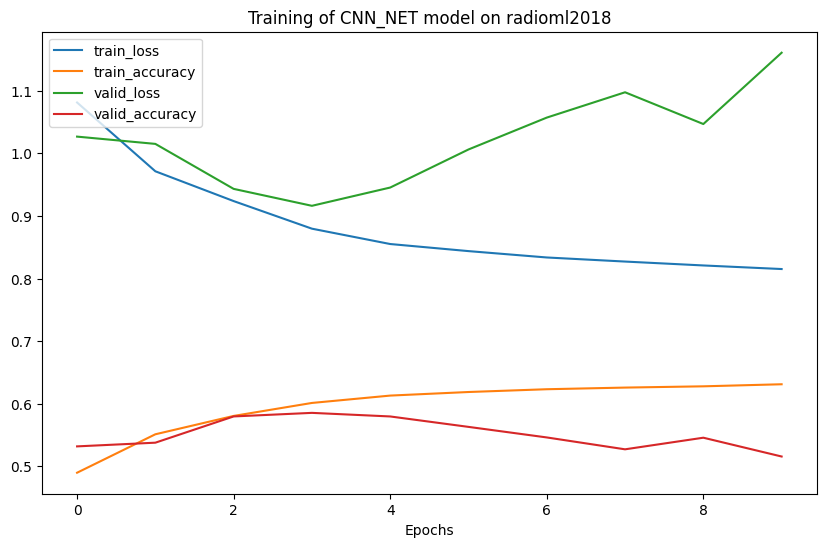


Evaluating and plotting test accuracy...
target modulation:['BPSK', 'QPSK', '8PSK', '16QAM', '32QAM', '64QAM']
target SNR: [-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]


Testing model: 100%|██████████| 1248/1248 [00:21<00:00, 58.07it/s]


Accuracy on test dataset: 52.05%
Modulation BPSK: 26624 test samples
Modulation QPSK: 26624 test samples
Modulation 8PSK: 26624 test samples
Modulation 16QAM: 26624 test samples
Modulation 32QAM: 26624 test samples
Modulation 64QAM: 26624 test samples


Calculating per-modulation accuracies: 100%|██████████| 6/6 [00:00<00:00, 23.79it/s, modulation=64QAM]


Highlighting PSK modulation: ['BPSK', 'QPSK', '8PSK']


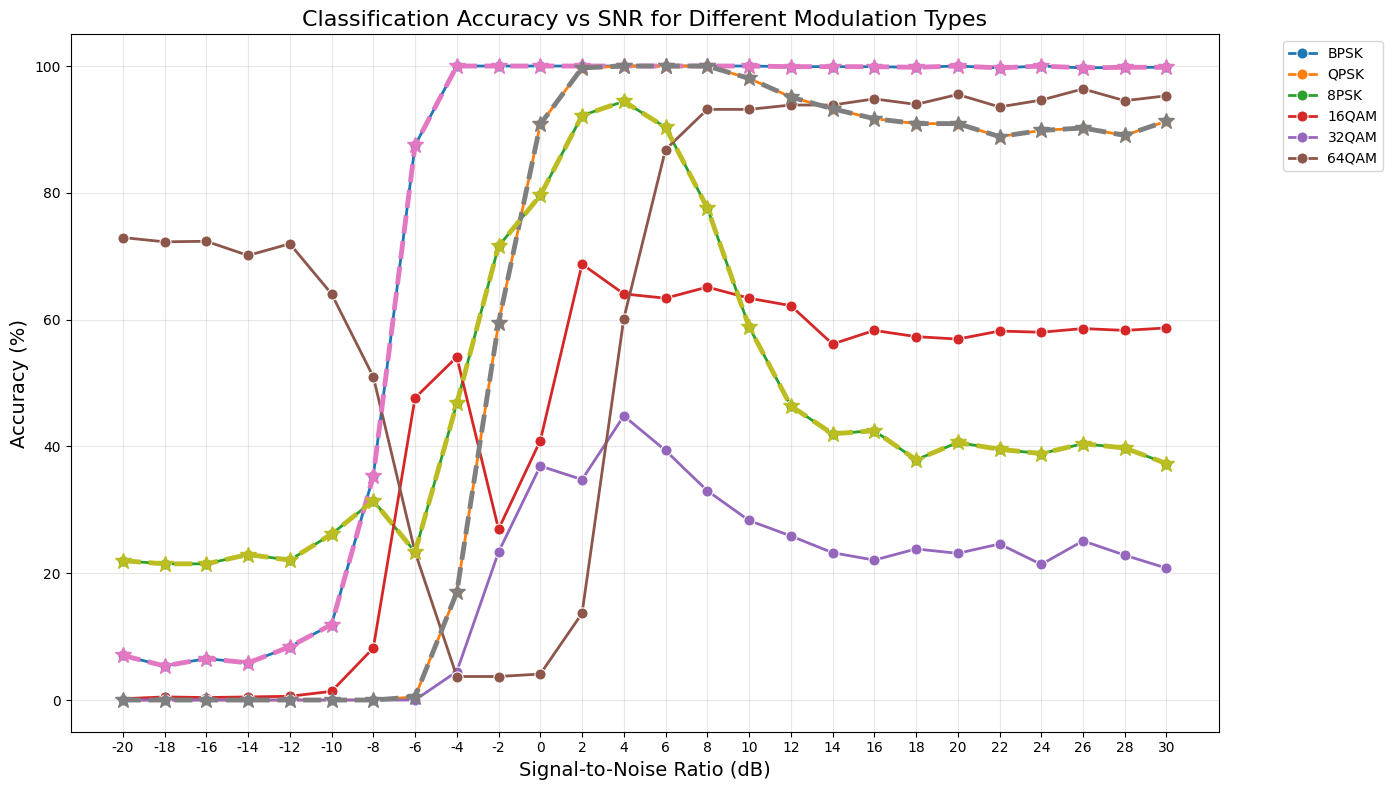

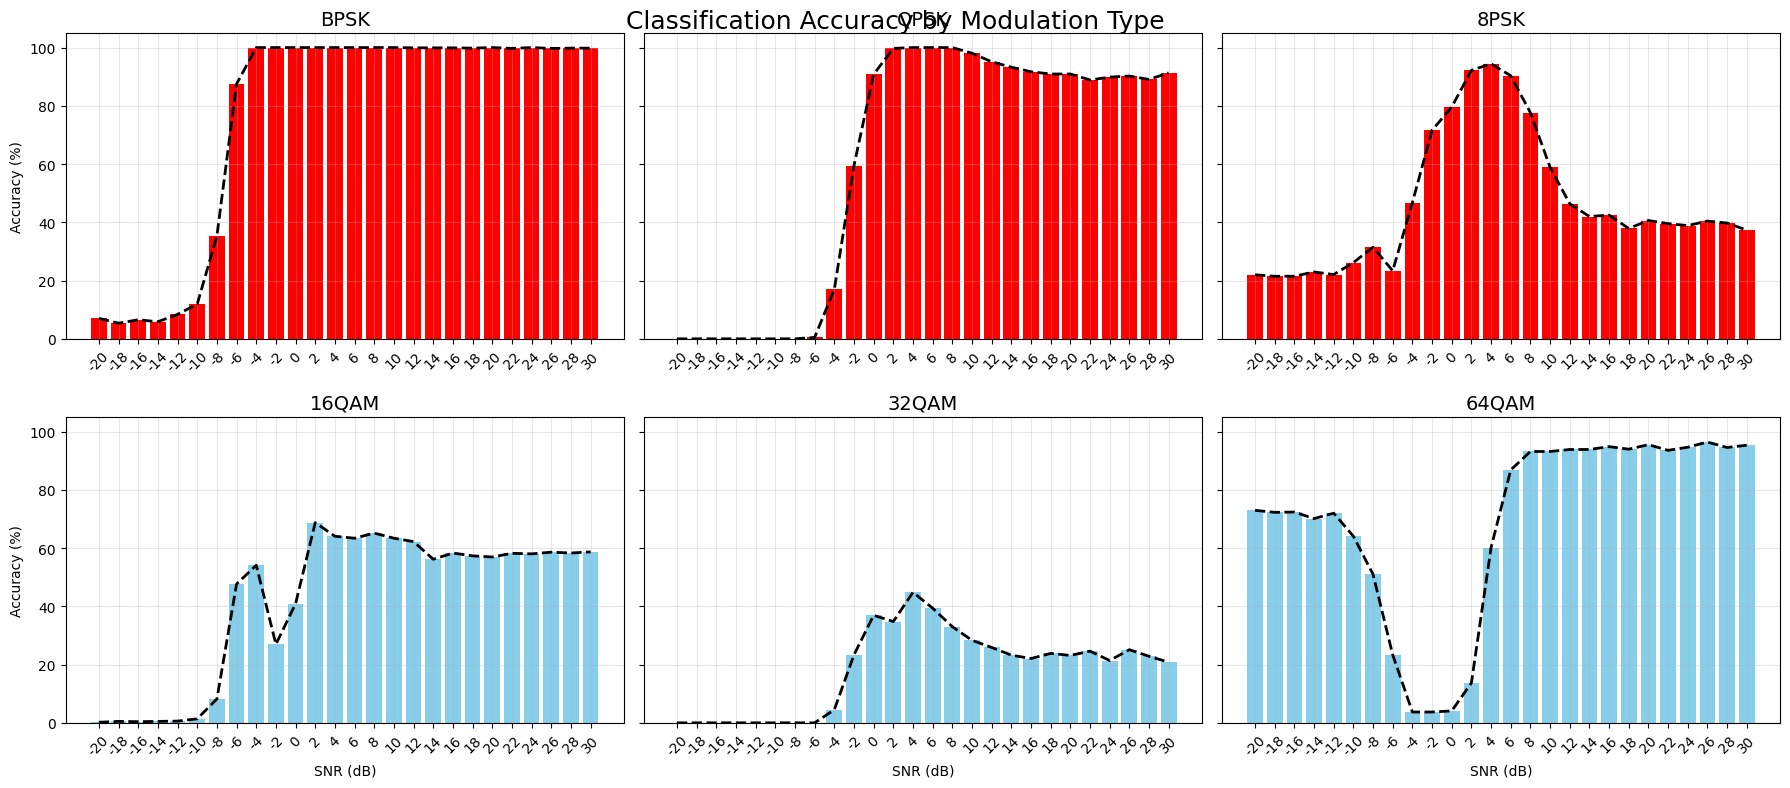

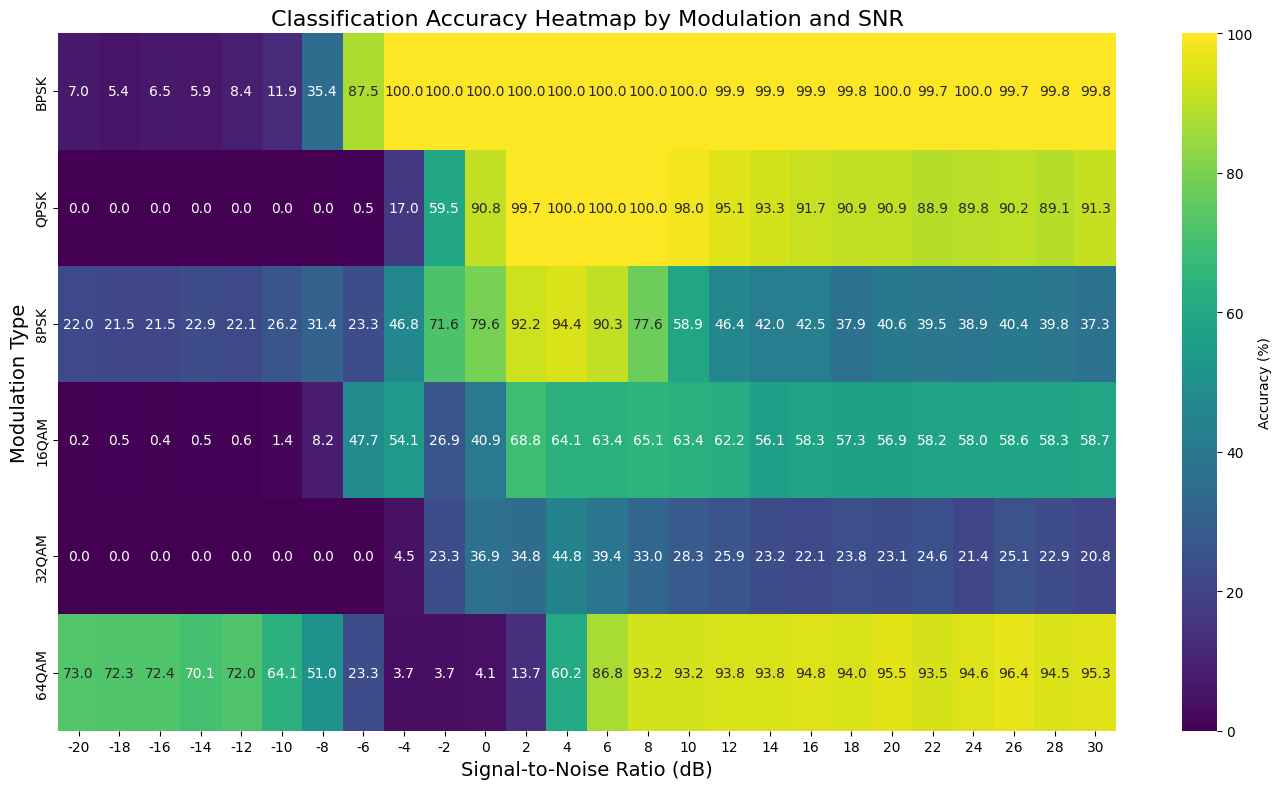

(CNN_NET(
   (backbone): Sequential(
     (0): CNN_Block(
       (block): Sequential(
         (0): Conv1d(2, 32, kernel_size=(3,), stride=(1,), padding=(1,))
         (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU(inplace=True)
         (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
         (4): Dropout(p=0.25, inplace=False)
       )
     )
     (1): CNN_Block(
       (block): Sequential(
         (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
         (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU(inplace=True)
         (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
         (4): Dropout(p=0.25, inplace=False)
       )
     )
     (2): CNN_Block(
       (block): Sequential(
         (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
         (1): BatchNorm1d(128, eps=1e-05

In [20]:
improved_train_test_plots(
    model=CNN_NET(n_labels), 
    model_name = 'CNN_NET', 
    device = 'cuda', 
    verbose = True, 
    num_epoch=10
)